In [93]:
import chromadb
#import openai
from chromadb.config import Settings
from chromadb import PersistentClient
import pandas as pd
import numpy as np

**Compare text description of each artefact**

In [19]:
#client.delete_collection("looted_text")
client = PersistentClient(path="./chroma_db")
collection = client.create_collection(
    name="looted_text",
    configuration={
        "hnsw": {
            "space": "cosine",       # recommandé pour du texte
            "ef_construction": 200,
            "ef_search": 150
        }
    }
)

In [20]:
df = pd.read_csv("../data/clean/artifacts_comparison.csv", sep = ';', encoding="utf-8-sig")

In [23]:
# Ajoutez les documents des textes web
collection.add(
    ids=[f"b_{i}" for i in range(len(df))] + [f"c_{i}" for i in range(len(df))],
    documents=df["wb_txt_shrt"].tolist() + df["wb_txt_lg"].tolist(),
    metadatas=[{"source": "wb_txt_shrt", "artifact_id": str(v)} for v in df["artifact_id"]] +
              [{"source": "wb_txt_lg", "artifact_id": str(v)} for v in df["artifact_id"]],
)

# results for each
res_B = collection.query(
    query_texts=df["looted_text"].tolist(),
    n_results=1,
    where={"source": "wb_txt_shrt"},
    include=["distances", "metadatas"]
)

res_C = collection.query(
    query_texts=df["looted_text"].tolist(),
    n_results=1,
    where={"source": "wb_txt_lg"},
    include=["distances", "metadatas"]
)

# viz df
df["wb_txt_shrt_dist"] = [d[0] for d in res_B["distances"]]
df["wb_txt_lgidst"] = [d[0] for d in res_C["distances"]]


C:\Users\Utilisateur\.cache\chroma\onnx_models\all-MiniLM-L6-v2\onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:09<00:00, 8.92MiB/s]


In [26]:
df.to_csv("first_text_scoring.csv",sep = ';', encoding="utf-8-sig")

**Compare images of each artefact**

*Note: use of chroma db for testing, but dataset < 1k so not necessary, DINO2 en Hugging face could be a good option as well*

In [109]:
from chromadb.utils.data_loaders import ImageLoader
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction

In [111]:
client = chromadb.Client()

client.delete_collection("collection_pdf")

In [112]:
# get the pdf images
df = pd.read_csv("../data/clean/pdf_images.csv", sep = ';', encoding="utf-8-sig")
pdf_img = df[['artifact_id','image_path','image_name']]
ids_pdf = df['image_name'].astype(str).tolist()
pdf_paths = df['image_path'].astype(str).tolist()
pdf_artifacts = df['artifact_id'].astype(str).tolist()
#print(ids_pdf[0:2])
#print(pdf_paths[0:2])
#print(pdf_artifacts[0:2])

In [113]:
# get the web images
df = pd.read_csv("../data/clean/web_photos.csv", sep = ';', encoding="utf-8-sig")
web_img = df[['artifact_id','image_path','image_name']]
ids_web = df['image_name'].astype(str).tolist()
web_paths = df['image_path'].astype(str).tolist()
web_artifacts = df['artifact_id'].astype(str).tolist()

In [114]:
# create collections of images (fucntional set-up)
client = chromadb.Client()

collection_pdf = client.create_collection(
    name="collection_pdf",
    embedding_function=OpenCLIPEmbeddingFunction(),
    data_loader=ImageLoader(),
    configuration={
        "hnsw": {
            "space": "cosine",
            "ef_construction": 200,
            "ef_search": 150
        }
    }
)


collection_web = client.create_collection(
    name="collection_web",
    embedding_function=OpenCLIPEmbeddingFunction(),
    data_loader=ImageLoader(),
    configuration={
        "hnsw": {
            "space": "cosine",
            "ef_construction": 200,
            "ef_search": 150
        }
    }
)

In [115]:
# Add images (note: metadata enables to store artifact_id)
# PDF with extracted ids
metadatas_pdf = [
    {"common_id": artifact, "source": "pdf"}
    for artifact in pdf_artifacts
]

collection_pdf.add(
    ids=ids_pdf,
    uris=pdf_paths,
    metadatas= metadatas_pdf
)

# WEB with extracted ids
metadatas_web = [
    {"common_id": artifact, "source": "web"}
    for artifact in web_artifacts
]

collection_web.add(
    ids=ids_web,
    uris=web_paths,
    metadatas=metadatas_web
)

In [116]:
pdf_set = set(pdf_artifacts)
web_set = set(web_artifacts)
common_ids = pdf_set & web_set

results = {}

for artifact_id in common_ids:
    pdf_images = collection_pdf.get(
        where={"common_id": artifact_id},
        include=["embeddings"]
    )
    
    if len(pdf_images["embeddings"]) > 0:
        query_results = collection_web.query(
            query_embeddings=pdf_images["embeddings"],
            where={"common_id": artifact_id},
            n_results=10,
            include=["distances", "metadatas"]
        )
        results[artifact_id] = query_results

  
# Voir les résultats
#for key, value in results.items():
    #print(f"Artifact {key}: distances = {value['distances']}")

In [117]:
import pandas as pd

rows = []

for artifact_id in common_ids:
    pdf_images = collection_pdf.get(
        where={"common_id": artifact_id},
        include=["embeddings", "metadatas"]
    )
    
    if len(pdf_images["embeddings"]) > 0:
        query_results = collection_web.query(
            query_embeddings=pdf_images["embeddings"],
            where={"common_id": artifact_id},
            n_results=10,
            include=["distances", "metadatas"]
        )
        
        # for each pdf image
        for i, pdf_id in enumerate(pdf_images["ids"]):
            # for each compared web image
            for j, web_id in enumerate(query_results["ids"][i]):
                rows.append({
                    "artifact_id": artifact_id,
                    "image_pdf": pdf_id,
                    "image_web": web_id,
                    "score": query_results["distances"][i][j]
                })

df_results = pd.DataFrame(rows)
# .loc to get the full row, idx to get consistent and corresponding image_pdf, and image_web and min score
best = df_results.loc[df_results.groupby("artifact_id")["score"].idxmin()]


In [124]:
best.to_csv("../data/clean/best_image_score.csv", encoding = "utf-8-sig")

**Create the final scoring**

In [119]:
score_txt = pd.read_csv("../data/clean/first_text_scoring.csv", sep = ";", encoding="utf-8-sig")
score_img = pd.read_csv("../data/clean/best_image_score.csv", sep = ",", encoding="utf-8-sig")
score_txt['score_txt'] = score_txt[['wb_txt_shrt_dist','wb_txt_shrt_dist']].min(axis = 1)
score_img.rename(columns = {'score':'score_img'}, inplace=True)

#artifact_score = score_txt.merge(score_img, on = 'artifact_id', how = 'outer')
artifact_score[['score_txt','score_img']] = artifact_score[['score_txt','score_img']].replace(np.nan,0)
artifact_score['final_score'] = (artifact_score['score_img'] + artifact_score['score_txt'])/2
final_score = artifact_score[['artifact_id', 'score_txt', 'score_img', 'final_score']]
def conditions(row):
    if (row['score_txt'] == 0) & (row['score_img'] != 0):
        val = 'score_img only'
    elif (row['score_txt'] != 0) & (row['score_img'] == 0):
        val = 'score_txt only'
    else:
        val = 'combined score'  
    return val

#Apply the function to each data point in the data frame
final_score['score_type']= final_score.apply(conditions, axis=1)
final_score.to_csv("../data/clean/final_score.csv", encoding = 'utf-8-sig')
final_score.head(5)

,artifact_id,score_txt,score_img,final_score,score_type
0,0-آثارنا المنهوبة 30_p003_2e0f1399,0.290426,0.049638,0.170032,combined score
1,0-آثارنا المنهوبة 30_p004_e96b4190,0.420321,0.139458,0.279890,combined score
2,0-آثارنا المنهوبة 30_p006_6686f187,0.311579,0.103621,0.207600,combined score
3,0-آثارنا المنهوبة 30_p007_f4603e0c,0.272519,0.043664,0.158091,combined score
4,0-آثارنا المنهوبة 30_p008_6098ac5e,0.355542,0.134479,0.245011,combined score


In [121]:
final_score.describe()

,score_txt,score_img,final_score
count,246.000000,246.000000,246.000000
mean,0.320816,0.081807,0.201311
std,0.119451,0.168934,0.079672
min,0.000000,0.000000,0.000343
25%,0.282907,0.000000,0.160836
50%,0.338189,0.032827,0.196418
75%,0.401839,0.070609,0.229478
max,0.518909,0.962525,0.626723


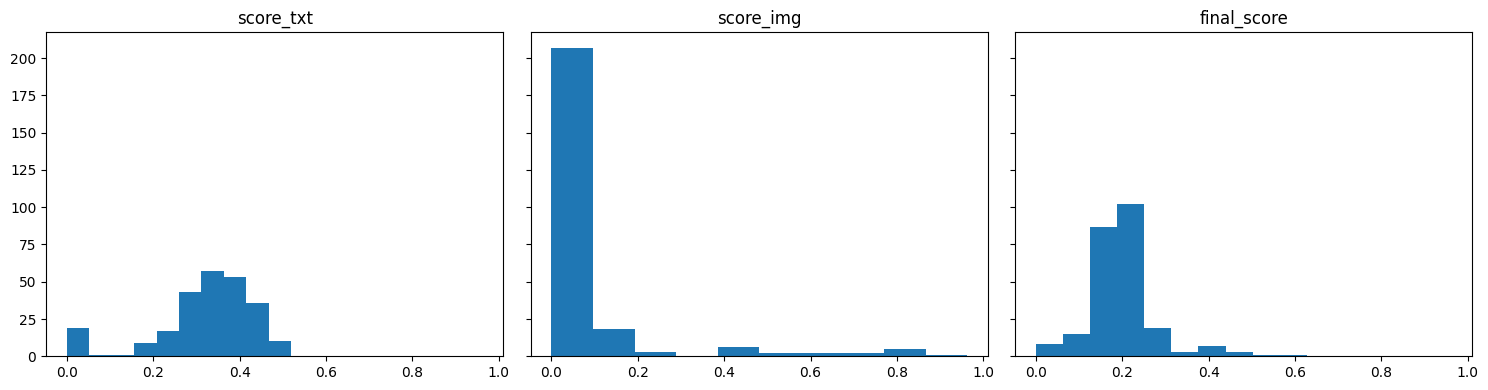

In [122]:
# loop on plots
columns = final_score[['score_txt', 'score_img', 'final_score']]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
#very cool the shared axes

for i, col in enumerate(columns):
    axes[i].hist(final_score[col].dropna())
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig("../figures/score_histograms.png")
plt.show()

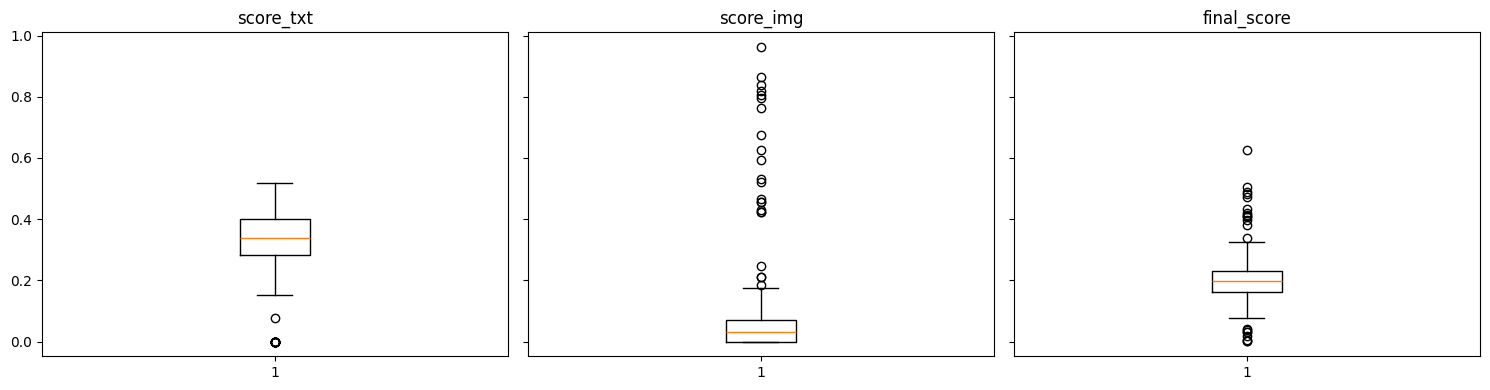

In [123]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, col in enumerate(columns):
    axes[i].boxplot(final_score[col].dropna())
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig("../figures/score_bplots.png")
plt.show()